## **0. Clone PrePath**

In [1]:
!git clone https://github.com/birkhoffkiki/PrePATH

Cloning into 'PrePATH'...
remote: Enumerating objects: 628, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (129/129), done.
remote: Total 628 (delta 169), reused 191 (delta 122), pack-reused 364 (from 1)
Receiving objects: 100% (628/628), 13.25 MiB | 8.99 MiB/s, done.
Resolving deltas: 100% (334/334), done.


### 0.1 Library Installation

In [1]:
%cd /datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH

/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH


In [ ]:
!pip install torch==2.3.0 \
torchvision==0.18.0 \
timm==1.0.15 \
wandb \
openslide-python \
openslide-bin h5py==3.8.0 \
numpy==1.26.4 \
opencv_python==4.7.0.72 \
opencv_python_headless==4.10.0.84 \
paramiko==3.5.1 \
pathos==0.3.3 \
Pillow==11.2.1 \
PyYAML==6.0.2 \
scipy==1.15.3 \
scp==0.15.0 \
setuptools==65.6.3 \
pandas einops_exts

## **1. Download WSIs from GDC client**

### 1.1. Prepare directory to download data from GDC client

In [4]:
!mkdir downloaded_data

In [2]:
%cd downloaded_data

/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/downloaded_data


In [3]:
!mkdir TCGA-BRCA

In [4]:
%cd TCGA-BRCA

/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/downloaded_data/TCGA-BRCA


In [ ]:
# !gdown --id 1dsu9Drmeme5Of3EKt0KBAQOyEUfU84gv

In [ ]:
# !chmod 777 ./gdc-client

In [ ]:
# !./gdc-client download -m ./gdc_manifest.2025-10-20.154101.txt

In [5]:
%cd /datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH

/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH


### 2.1. WSI patching

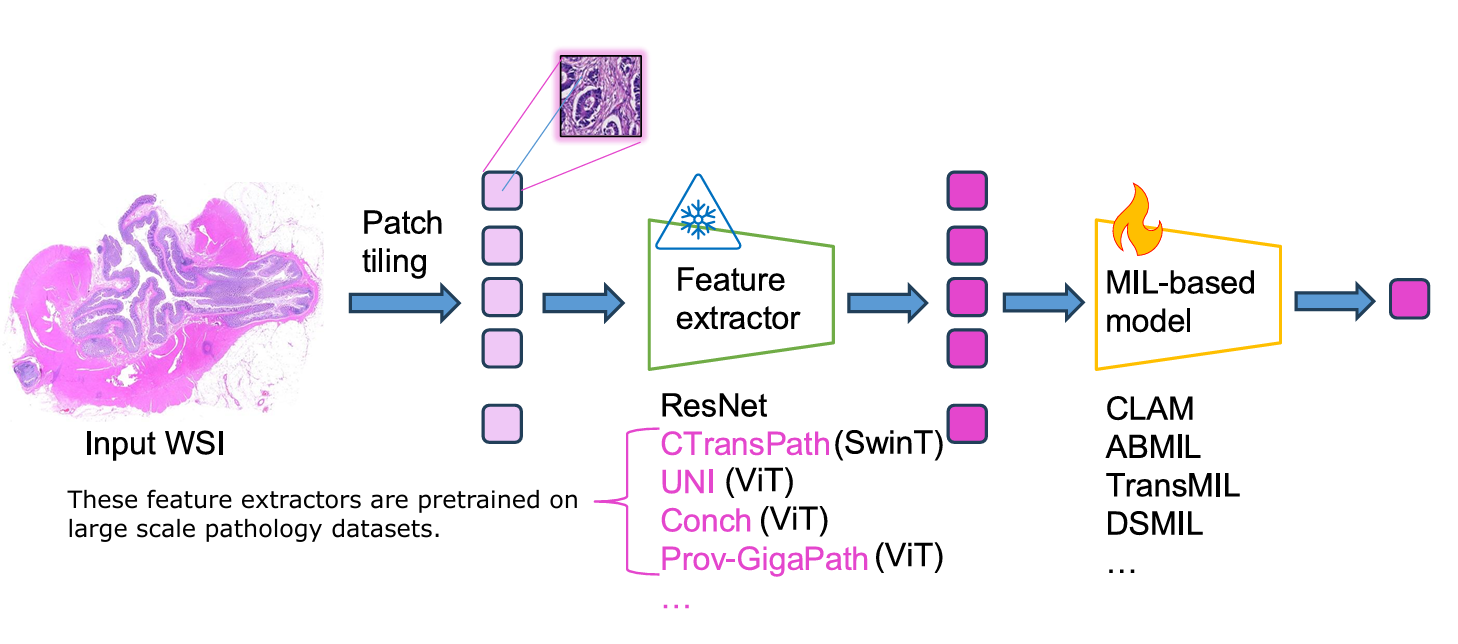

Note: Fix line 139 in `create_patches_fp.py`:
```
full_path = os.path.join(slide)
```

In [ ]:
# The coordinates of the patches are saved, you can change the path to any directory you want.
save_dir="./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches"
# The directory where the WSI files are stored, you can change it to any directory you want.
wsi_dir="/datastore/uittogether3/LuuTru/Thanhld/WSI/dataset/TCGA-BRCA"
# The WSI format, you can set it based on the format of your WSI
wsi_format="svs" # .tiff, .svs
# The log file name, you can change it to any name you want.
log_name="TCGA-BRCA.log"

# Normally, you don't need to change following lines.
# to set the patch size, please set it at `configs/resolution.py`
# 0: 40x, 1: 10x, 2: 5x, 4: 2.5x
!python create_patches_fp.py \
        --source $wsi_dir \
        --save_dir $save_dir --preset tcga.csv \
        --patch_level 1 \
        --wsi_format $wsi_format \
        --seg \
        --patch \
        --stitch

source:  /datastore/uittogether3/LuuTru/Thanhld/WSI/dataset/TCGA-BRCA
patch_save_dir:  ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches/patches
mask_save_dir:  ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches/masks
stitch_save_dir:  ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches/stitches
source : /datastore/uittogether3/LuuTru/Thanhld/WSI/dataset/TCGA-BRCA
save_dir : ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches
patch_save_dir : ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches/patches
mask_save_dir : ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches/masks
stitch_save_dir : ./downloaded_data/TCGA-BRCA/TCGA-BRCA_patches/stitches
{'seg_params': {'seg_level': -1, 'sthresh': 8, 'mthresh': 7, 'close': 4, 'use_otsu': True, 'keep_ids': 'none', 'exclude_ids': 'none'}, 'filter_params': {'a_t': 16, 'a_h': 4, 'max_n_holes': 8}, 'patch_params': {'use_padding': True, 'contour_fn': 'four_pt'}, 'vis_params': {'vis_level': -1, 'line_thickness': 100}}
{'source': '/datastore/uittogether3/LuuTru/Thanhld/WSI/dataset/TCG

### 2.2. Extract features (use vision encoder of TITAN (CONCHv1.5))

In [17]:
!mkdir scripts/extract_feature/logs

mkdir: cannot create directory ‘scripts/extract_feature/logs’: File exists


In [ ]:
# Tải checkpoint của CONCHv1.5 (TITAN vision encoder)
!mkdir /datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/models/ckpts
%cd /datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/models/ckpts
# !gdown --id 1QmH-dZJ6lr540XGAdZA5-IjkUv8ITHST
# !mv "conch_v1_5_pytorch_model.bin" "conch1.5.bin"

mkdir: cannot create directory ‘/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/models/ckpts’: File exists
/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/models/ckpts
/bin/bash: line 1: gdown: command not found
mv: cannot stat 'conch_v1_5_pytorch_model.bin': No such file or directory


In [ ]:
# Tải checkpoint của CONCHv1.5 từ Hugging Face
# Repo MahmoodLab/conchv1_5 không có config.json cho timm hf_hub,
# nên cần tải trực tiếp file pytorch_model_vision.bin rồi đổi tên thành conch1.5.bin
import os
from getpass import getpass
from pathlib import Path

import shutil
from huggingface_hub import hf_hub_download

ckpt_dir = Path("/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH/models/ckpts")
ckpt_dir.mkdir(parents=True, exist_ok=True)
ckpt_path = ckpt_dir / "conch1.5.bin"

token = os.environ.get("HF_TOKEN")
if not token:
    token = getpass("Nhập Hugging Face token: ")
token = token.strip()

downloaded = hf_hub_download(
    repo_id="MahmoodLab/conchv1_5",
    filename="pytorch_model_vision.bin",
    token=token,
)
shutil.copy2(downloaded, ckpt_path)
print(f"Saved checkpoint to {ckpt_path}")


In [ ]:
%cd /datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH
!mkdir csv

TASK_NAME="CESC_feats_conch15"   # Task name, change it as you want

csv_path="csv/" + TASK_NAME
!mkdir $csv_path

# auto generate csv
!python scripts/extract_feature/generate_csv.py \
        --h5_dir "./downloaded_data/CESC_patches/patches" \
        --num 1 \
        --root "csv/CESC_feats_conch15"

# !python extract_features_fp_fast.py \
#         --model "conch15" \
#         --csv_path "./csv/CESC_feats_conch15/part_0.csv" \
#         --data_coors_dir "./downloaded_data/CESC_patches" \
#         --data_slide_dir "./downloaded_data/CESC" \
#         --feat_dir "./downloaded_data/CESC_feats_conch15" \
#         --ignore_partial yes \
#         --batch_size 32 \
#         --datatype auto \
#         --slide_ext ".svs" \
#         --save_storage "yes"

/datastore/uittogether3/LuuTru/Thanhld/WSI/MergeSlide_TTA/notebooks/PrePATH
